# Question 4: Polynomial Regression and Ridge Regularization

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_poly_features(x, degree):
    X = np.ones((len(x), 1))
    for d in range(1, degree + 1):
        X = np.hstack((X, (x ** d).reshape(-1, 1)))
    return X

def fit_normal_equation(X, y, lambda_reg=0):
    n_features = X.shape[1]
    I = np.eye(n_features)
    theta = np.linalg.inv(X.T @ X + lambda_reg * I) @ X.T @ y
    return theta

def predict(X, theta):
    return X @ theta

def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

## Part (A): Polynomial Regression on Dataset A

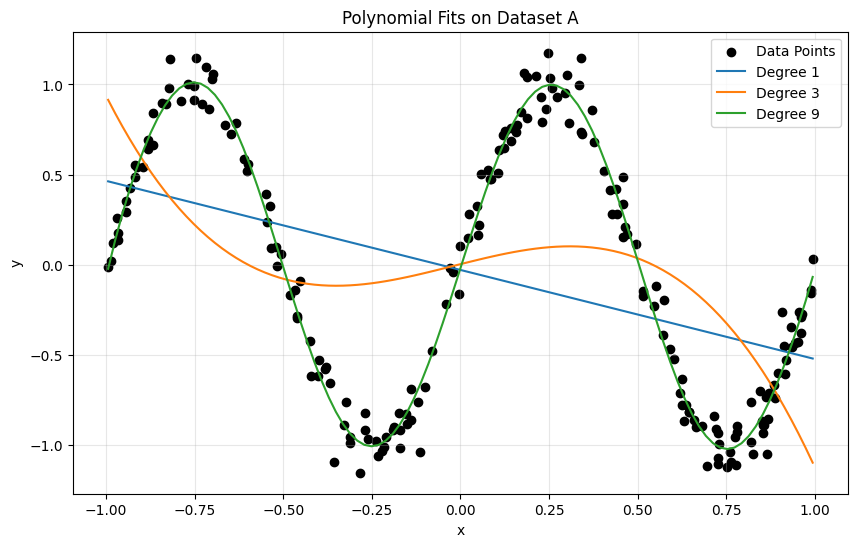

In [3]:
df_a = pd.read_csv('data/data_A.csv')
x_a = df_a['x'].values
y_a = df_a['y'].values

degrees = [1, 3, 9]
x_grid = np.linspace(x_a.min(), x_a.max(), 100)

plt.figure(figsize=(10, 6))
plt.scatter(x_a, y_a, color='black', label='Data Points')

for d in degrees:
    X_train = get_poly_features(x_a, d)
    theta = fit_normal_equation(X_train, y_a)
    
    X_grid = get_poly_features(x_grid, d)
    y_grid = predict(X_grid, theta)
    
    plt.plot(x_grid, y_grid, label=f'Degree {d}')

plt.title('Polynomial Fits on Dataset A')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part (B.1): Effect of Polynomial Degree on Dataset B

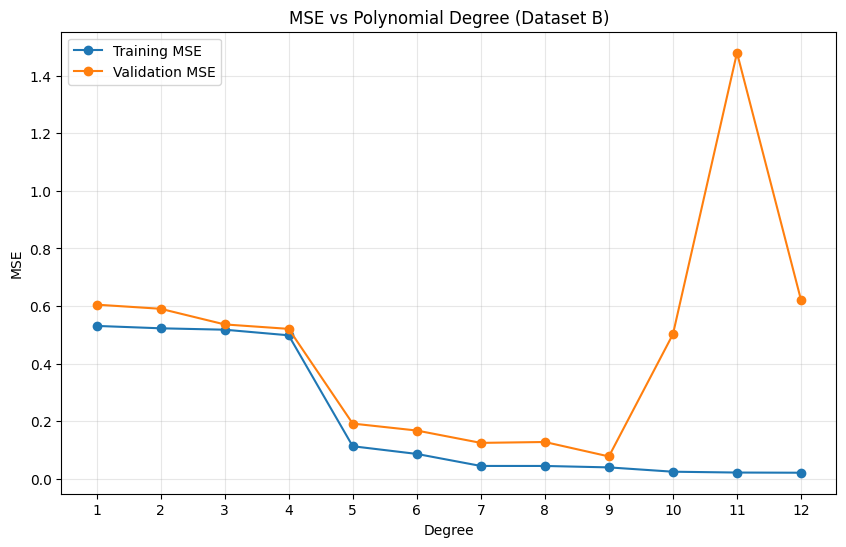

Degrees: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Train MSEs: [0.5306 0.5223 0.5175 0.498  0.1126 0.0859 0.0441 0.044  0.0391 0.024
 0.0212 0.0205]
Val MSEs: [0.6045 0.5902 0.5359 0.5204 0.1913 0.1671 0.1242 0.1273 0.0771 0.5019
 1.4799 0.6202]


In [4]:
df_b_train = pd.read_csv('data/data_B_train.csv')
df_b_val = pd.read_csv('data/data_B_val.csv')

x_train = df_b_train['x'].values
y_train = df_b_train['y'].values
x_val = df_b_val['x'].values
y_val = df_b_val['y'].values

train_mses = []
val_mses = []
degrees_range = range(1, 13)

for d in degrees_range:
    X_train = get_poly_features(x_train, d)
    X_val = get_poly_features(x_val, d)
    
    theta = fit_normal_equation(X_train, y_train, lambda_reg=0)
    
    y_train_pred = predict(X_train, theta)
    y_val_pred = predict(X_val, theta)
    
    train_mses.append(calculate_mse(y_train, y_train_pred))
    val_mses.append(calculate_mse(y_val, y_val_pred))

plt.figure(figsize=(10, 6))
plt.plot(degrees_range, train_mses, marker='o', label='Training MSE')
plt.plot(degrees_range, val_mses, marker='o', label='Validation MSE')
plt.title('MSE vs Polynomial Degree (Dataset B)')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.xticks(degrees_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Degrees:", list(degrees_range))
print("Train MSEs:", np.round(train_mses, 4))
print("Val MSEs:", np.round(val_mses, 4))

## Part (B.2): Ridge Regularization on Dataset B

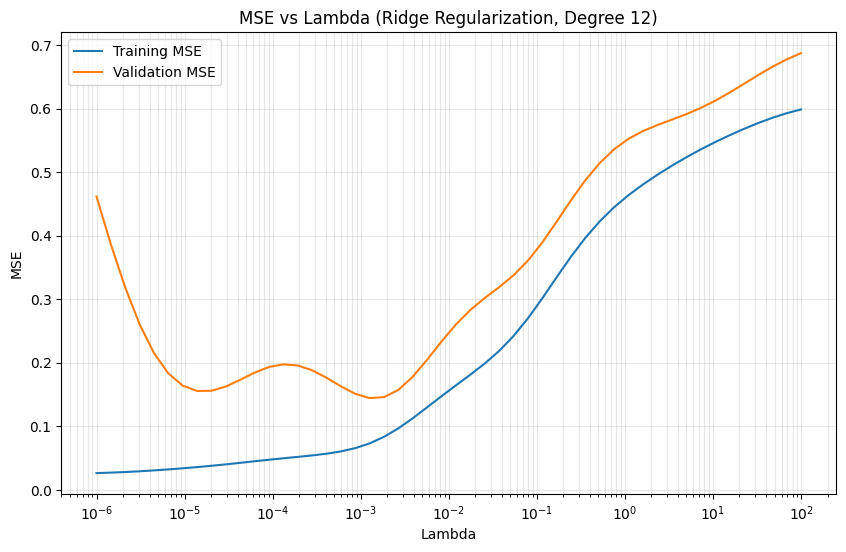

Minimum Validation MSE: 0.1444 at Lambda: 0.001265


In [5]:
degree_fixed = 12
lambdas = np.logspace(-6, 2, 50)

X_train_d12 = get_poly_features(x_train, degree_fixed)
X_val_d12 = get_poly_features(x_val, degree_fixed)

train_mses_ridge = []
val_mses_ridge = []

for lam in lambdas:
    theta = fit_normal_equation(X_train_d12, y_train, lambda_reg=lam)
    
    y_train_pred = predict(X_train_d12, theta)
    y_val_pred = predict(X_val_d12, theta)
    
    train_mses_ridge.append(calculate_mse(y_train, y_train_pred))
    val_mses_ridge.append(calculate_mse(y_val, y_val_pred))

plt.figure(figsize=(10, 6))
plt.plot(lambdas, train_mses_ridge, label='Training MSE')
plt.plot(lambdas, val_mses_ridge, label='Validation MSE')
plt.xscale('log')
plt.title(f'MSE vs Lambda (Ridge Regularization, Degree {degree_fixed})')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.show()

min_val_mse = min(val_mses_ridge)
best_lambda = lambdas[np.argmin(val_mses_ridge)]
print(f"Minimum Validation MSE: {min_val_mse:.4f} at Lambda: {best_lambda:.6f}")